In [2]:
# ==========================================
# 1. Import Libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, LSTM
from tensorflow.keras.callbacks import EarlyStopping

In [3]:


# ==========================================
# 2. Upload Dataset
# ==========================================
uploaded = files.upload()   # upload data.csv

df = pd.read_csv("data.csv")

print("First 5 rows:")
print(df.head())

print("\nColumns:")
print(df.columns)

Saving data.csv to data.csv
First 5 rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_wors

In [4]:


# ==========================================
# 3. Preprocessing
# ==========================================
df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for CNN / LSTM
X_train_seq = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_seq = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)


Feature shape: (569, 30)
Target shape: (569,)


In [5]:


# ==========================================
# 4. Model 1: MLP
# ==========================================
mlp_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(16, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop_mlp = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history_mlp = mlp_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_mlp],
    verbose=1
)

mlp_loss, mlp_accuracy = mlp_model.evaluate(X_test_scaled, y_test, verbose=0)
mlp_pred = (mlp_model.predict(X_test_scaled) > 0.5).astype("int32").flatten()

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 291ms/step - accuracy: 0.6181 - loss: 0.8012 - val_accuracy: 0.8132 - val_loss: 0.5829
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7308 - loss: 0.5143 - val_accuracy: 0.9231 - val_loss: 0.4611
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8104 - loss: 0.4035 - val_accuracy: 0.9341 - val_loss: 0.3722
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8984 - loss: 0.2737 - val_accuracy: 0.9670 - val_loss: 0.3118
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9093 - loss: 0.2563 - val_accuracy: 0.9560 - val_loss: 0.2689
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9341 - loss: 0.2062 - val_accuracy: 0.9451 - val_loss: 0.2368
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9451 - loss: 0.1787 - val_accuracy: 0.9451 - val_loss: 0.2137
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9313 - loss: 0.2005 - val_accuracy: 0.9451 -

In [6]:


# ==========================================
# 5. Model 2: 1D CNN
# ==========================================
cnn_model = Sequential([
    Input(shape=(X_train_seq.shape[1], 1)),
    Conv1D(32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop_cnn = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history_cnn = cnn_model.fit(
    X_train_seq, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_cnn],
    verbose=1
)

cnn_loss, cnn_accuracy = cnn_model.evaluate(X_test_seq, y_test, verbose=0)
cnn_pred = (cnn_model.predict(X_test_seq) > 0.5).astype("int32").flatten()

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 204ms/step - accuracy: 0.8434 - loss: 0.4884 - val_accuracy: 0.9121 - val_loss: 0.2862
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9121 - loss: 0.2412 - val_accuracy: 0.9121 - val_loss: 0.2108
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9478 - loss: 0.1643 - val_accuracy: 0.9341 - val_loss: 0.1744
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9670 - loss: 0.1246 - val_accuracy: 0.9560 - val_loss: 0.1572
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9725 - loss: 0.0973 - val_accuracy: 0.9341 - val_loss: 0.1451
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9780 - loss: 0.0747 - val_accuracy: 0.9341 - val_loss: 0.1431
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9753 - loss: 0.0762 - val_accuracy: 0.9341 - val_loss: 0.1450
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9753 - loss: 0.0805 - val_accuracy: 0.9341 -

In [7]:


# ==========================================
# 6. Model 3: LSTM
# ==========================================
lstm_model = Sequential([
    Input(shape=(X_train_seq.shape[1], 1)),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop_lstm = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history_lstm = lstm_model.fit(
    X_train_seq, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_lstm],
    verbose=1
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(X_test_seq, y_test, verbose=0)
lstm_pred = (lstm_model.predict(X_test_seq) > 0.5).astype("int32").flatten()

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.8297 - loss: 0.6326 - val_accuracy: 0.8901 - val_loss: 0.5201
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8901 - loss: 0.4084 - val_accuracy: 0.9121 - val_loss: 0.2789
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9176 - loss: 0.3288 - val_accuracy: 0.9341 - val_loss: 0.2172
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9286 - loss: 0.2540 - val_accuracy: 0.9560 - val_loss: 0.1975
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9286 - loss: 0.2485 - val_accuracy: 0.9451 - val_loss: 0.1911
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9313 - loss: 0.2507 - val_accuracy: 0.9451 - val_loss: 0.1863
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9313 - loss: 0.2371 - val_accuracy: 0.9451 - val_loss: 0.1976
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9341 - loss: 0.2465 - val_accuracy: 0.

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [8]:


# ==========================================
# 7. Model 4: Random Forest
# ==========================================
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

In [9]:


# ==========================================
# 8. Model 5: Logistic Regression
# ==========================================
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, lr_pred)

In [10]:

# ==========================================
# 9. Model 6: SVM
# ==========================================
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_accuracy = accuracy_score(y_test, svm_pred)

In [11]:



# ==========================================
# 10. Print Results
# ==========================================
models_results = [
    ("MLP", mlp_accuracy, mlp_pred),
    ("1D CNN", cnn_accuracy, cnn_pred),
    ("LSTM", lstm_accuracy, lstm_pred),
    ("Random Forest", rf_accuracy, rf_pred),
    ("Logistic Regression", lr_accuracy, lr_pred),
    ("SVM", svm_accuracy, svm_pred),
]

for name, acc, pred in models_results:
    print(f"\n========== {name} Results ==========")
    print("Accuracy:", acc)
    print("\nClassification Report:\n", classification_report(y_test, pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, pred))


========== MLP Results ==========
Accuracy: 0.9736841917037964

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

Confusion Matrix:
 [[72  0]
 [ 3 39]]

========== 1D CNN Results ==========
Accuracy: 0.9649122953414917

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Confusion Matrix:
 [[71  1]
 [ 3 39]]

========== LSTM Results ==========
Accuracy: 0.9385964870452881

Classification Report:



========== Final Model Comparison ==========
                 Model  Accuracy
5                  SVM  0.973684
0                  MLP  0.973684
1               1D CNN  0.964912
3        Random Forest  0.964912
4  Logistic Regression  0.964912
2                 LSTM  0.938596


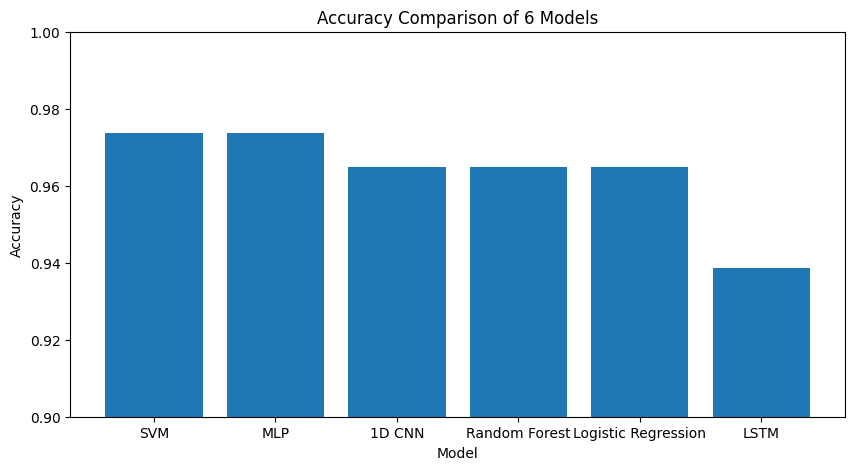

In [12]:


# ==========================================
# 11. Comparison Table
# ==========================================
comparison = pd.DataFrame({
    "Model": [x[0] for x in models_results],
    "Accuracy": [x[1] for x in models_results]
})

comparison = comparison.sort_values(by="Accuracy", ascending=False)

print("\n========== Final Model Comparison ==========")
print(comparison)

plt.figure(figsize=(10, 5))
plt.bar(comparison["Model"], comparison["Accuracy"])
plt.title("Accuracy Comparison of 6 Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.90, 1.00)
plt.show()

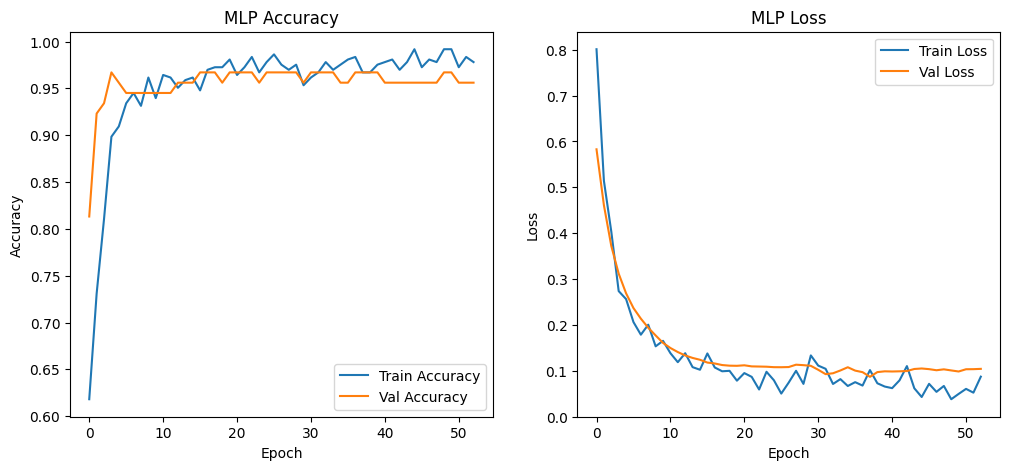

In [13]:


# ==========================================
# 12. Plot Training History for MLP
# ==========================================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_mlp.history['accuracy'], label='Train Accuracy')
plt.plot(history_mlp.history['val_accuracy'], label='Val Accuracy')
plt.title('MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_mlp.history['loss'], label='Train Loss')
plt.plot(history_mlp.history['val_loss'], label='Val Loss')
plt.title('MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

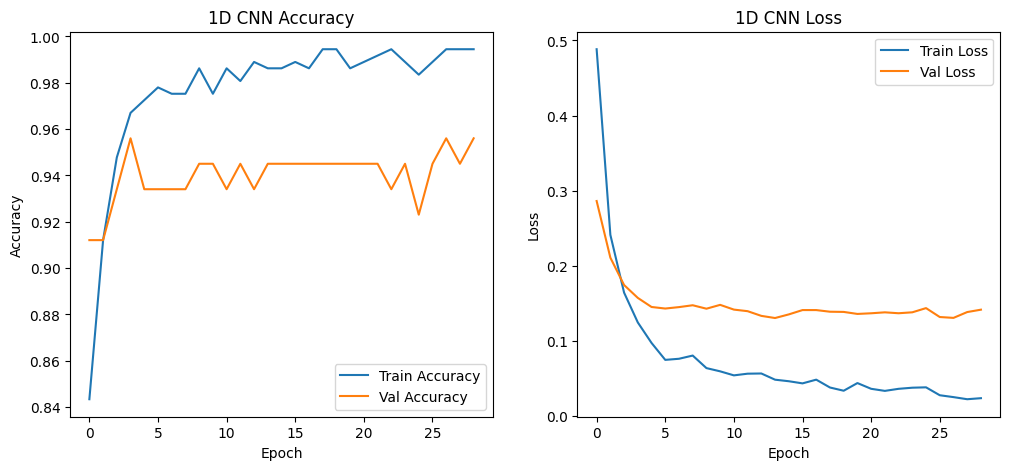

In [14]:


# ==========================================
# 13. Plot Training History for CNN
# ==========================================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
plt.title('1D CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title('1D CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

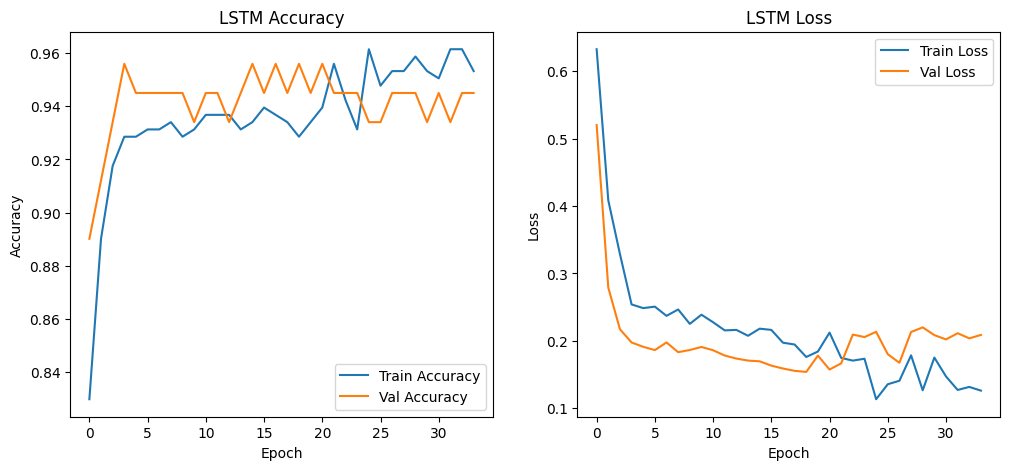

In [15]:


# ==========================================
# 14. Plot Training History for LSTM
# ==========================================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Val Accuracy')
plt.title('LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()